# Online Store Order Analysis - April 2026

## Goal of Analysis: 

Analyze online store orders to understand:

- Revenue performance
- Customer behavior
- Product category performance
- Return rates
- Data quality issues


---

# Stage 1: Data Understanding

## Goal 

Get an an initial understanding of the dataset


In [1]:
# Import Libraries

import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Import input file for use: 
input_file = "/Users/spencerwillard/code/local/quick_analyses/customer_data_project_20260608/input_data/orders_10k_messy.csv" 

In [3]:
# Create Original DataFrame
raw_df = pd.read_csv(input_file)

In [4]:
# How many columns x rows? 
raw_df.shape

(10050, 11)

In [5]:
# Check quick sample of DF
raw_df.sample(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
2008,102008,C02363,2025-07-06,2025-07-14,AZ,Sports,1,210.67,0.05,False,Paid
5797,105797,C01869,2025-12-16,2025-12-24,AZ,Electronics,5,1361.15,0.15,False,Paid
3444,103444,C02753,2025-05-24,2025-05-29,AZ,Sports,4,1189.01,0.05,False,Pending
3843,103843,C00901,2025-10-16,2025-10-23,FL,Furniture,5,850.58,0.15,False,Paid
8200,108200,C01320,2025-05-18,2025-05-27,CA,Clothing,4,965.21,0.15,False,Paid
4111,104111,C01439,2025-05-20,2025-05-26,TX,Electronics,1,890.82,0.05,False,Paid
1126,101126,C02562,2025-04-08,2025-04-15,OR,Electronics,2,366.41,0.00,False,Pending
5173,105173,C01003,2025-02-23,2025-02-24,AZ,Books,2,1234.74,0.05,False,Paid
7392,107392,C00851,2025-03-21,2025-03-24,FL,Clothing,5,546.88,0.20,False,Paid
5891,105891,C01255,2025-04-02,2025-04-07,AZ,Clothing,7,1105.37,NaN,False,Paid


In [6]:
# Check out columns, missing data, data_Types
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10050 non-null  int64  
 1   customer_id       10050 non-null  str    
 2   order_date        10050 non-null  str    
 3   ship_date         9749 non-null   str    
 4   state             9852 non-null   str    
 5   product_category  10050 non-null  str    
 6   quantity          10050 non-null  str    
 7   unit_price        10050 non-null  str    
 8   discount          9950 non-null   float64
 9   returned          10050 non-null  bool   
 10  payment_status    10050 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(8)
memory usage: 795.1 KB


---

# Stage 2: Data Quality Assessment

## Goal

Understand what changes need to be made to original Dataframe to make it a clean datasent. 

In [7]:
# Focus on missing values
raw_df.isna().sum()

order_id              0
customer_id           0
order_date            0
ship_date           301
state               198
product_category      0
quantity              0
unit_price            0
discount            100
returned              0
payment_status        0
dtype: int64

In [8]:
# What does the missing ship_date look like? 
raw_df.loc[raw_df["ship_date"].isna()].head(25)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
11,100011,C02926,2025-06-10,NaN,TX,Clothing,4,711.5,0.15,False,Pending
12,100012,C02207,2025-08-27,NaN,CO,Clothing,6,1269.02,0.05,False,Paid
106,100106,C02341,2025-10-09,NaN,NY,Sports,4,281.79,0.15,False,Paid
125,100125,C01696,2025-04-21,NaN,NY,Electronics,1,304.47,0.15,False,Pending
152,100152,C02753,2025-05-26,NaN,CA,Furniture,2,60.9,0.05,False,Paid
159,100159,C02351,2025-09-19,NaN,CA,Electronics,4,1310.91,0.00,False,Paid
166,100166,C00964,2025-05-12,NaN,OR,Electronics,2,45.36,0.10,False,Paid
179,100179,C01503,2025-04-17,NaN,NY,Furniture,2,310.55,0.05,False,Paid
249,100249,C00125,2025-07-21,NaN,OR,Sports,6,814.53,0.10,False,Paid
286,100286,C00483,2025-09-29,NaN,NaN,Electronics,3,186.68,0.10,False,Paid


In [9]:
# What does the missing state look like?
raw_df.loc[raw_df["state"].isna()].head(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
137,100137,C00093,2025-04-11,2025-04-13,NaN,Clothing,7,635.71,0.00,False,Paid
197,100197,C00354,2025-10-30,2025-11-01,NaN,Electronics,3,1176.4,0.05,False,Paid
221,100221,C01367,2025-03-04,2025-03-08,NaN,Books,6,1190.61,0.15,False,Failed
266,100266,C01341,2025-05-01,2025-05-07,NaN,Electronics,4,460.64,0.20,False,Paid
286,100286,C00483,2025-09-29,NaN,NaN,Electronics,3,186.68,0.10,False,Paid
318,100318,C02816,2025-01-29,2025-02-07,NaN,Furniture,5,1421.25,0.20,False,Paid
340,100340,C01904,2025-08-22,2025-08-26,NaN,Clothing,6,1352.71,0.15,False,Paid
355,100355,C02977,2025-01-02,2025-01-09,NaN,Books,1,810.24,0.05,False,Paid
395,100395,C02623,2025-05-06,2025-05-13,NaN,Electronics,6,141.02,0.10,False,Paid
560,100560,C01610,2025-10-05,2025-10-11,NaN,Electronics,1,359.31,0.15,False,Paid


In [10]:
# What does the missing state look like?
raw_df.loc[raw_df["discount"].isna()].head(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
158,100158,C01515,2025-11-30,2025-12-06,FL,Sports,4,805.06,NaN,False,Paid
338,100338,C00609,2025-11-18,2025-11-20,WA,Clothing,4,1162.04,NaN,False,Paid
345,100345,C00768,2025-11-02,2025-11-10,OR,Sports,4,562.99,NaN,False,Paid
555,100555,C01514,2025-09-20,2025-09-25,AZ,Electronics,7,929.57,NaN,True,Paid
746,100746,C01597,2025-08-04,2025-08-05,FL,Electronics,2,446.22,NaN,False,Paid
781,100781,C01911,2025-07-25,2025-08-01,OR,Clothing,6,704.86,NaN,False,Paid
792,100792,C02168,2025-04-23,2025-04-25,CA,Sports,4,1051.93,NaN,False,Paid
858,100858,C02007,2025-02-23,2025-03-04,CA,Clothing,7,583.83,NaN,False,Paid
930,100930,C01613,2025-04-27,2025-05-02,WA,Sports,2,564.13,NaN,False,Paid
1044,101044,C02127,2025-03-20,2025-03-22,FL,Clothing,4,1388.71,NaN,False,Paid


In [11]:
# Do some checks for uniqueness
raw_df.nunique()

order_id            10000
customer_id          2876
order_date            365
ship_date             373
state                  10
product_category        8
quantity                9
unit_price           9670
discount                5
returned                2
payment_status          3
dtype: int64

In [12]:
# Create new DF of dupliated "order_id" 
duplicate_order_id = raw_df["order_id"].value_counts().reset_index()
duplicate_order_id

,order_id,count
0,100035,2
1,100039,2
2,100251,2
3,100321,2
4,100439,2
...,...,...
9995,109995,1
9996,109996,1
9997,109997,1
9998,109998,1


In [13]:
# Confirms that order_id is not unique 
duplicate_order_id.loc[duplicate_order_id["count"] >1].head(10)

,order_id,count
0,100035,2
1,100039,2
2,100251,2
3,100321,2
4,100439,2
5,100576,2
6,100582,2
7,101513,2
8,101731,2
9,101760,2


In [14]:
print(raw_df.duplicated().sum())
print(type(raw_df.duplicated().sum()))

50
<class 'numpy.int64'>


In [15]:
raw_df.loc[raw_df.duplicated(keep=False)].sort_values(by="order_id").head(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
35,100035,C00192,2025-06-27,2025-07-05,AZ,Furniture,1,1498.55,0.00,True,Paid
10041,100035,C00192,2025-06-27,2025-07-05,AZ,Furniture,1,1498.55,0.00,True,Paid
39,100039,C01895,2025-06-09,2025-06-16,WA,Sports,6,1166.44,0.05,False,Paid
10045,100039,C01895,2025-06-09,2025-06-16,WA,Sports,6,1166.44,0.05,False,Paid
251,100251,C01482,2025-01-16,2025-01-19,NY,Books,1,663.41,0.20,False,Paid
10037,100251,C01482,2025-01-16,2025-01-19,NY,Books,1,663.41,0.20,False,Paid
321,100321,C00324,2025-12-28,2025-12-30,CA,Furniture,7,1295.74,0.20,False,Paid
10030,100321,C00324,2025-12-28,2025-12-30,CA,Furniture,7,1295.74,0.20,False,Paid
439,100439,C01193,2025-02-14,2025-02-21,NY,Books,2,1417.65,0.05,True,Paid
10009,100439,C01193,2025-02-14,2025-02-21,NY,Books,2,1417.65,0.05,True,Paid


In [16]:
# Any inconsistent states? 
raw_df["state"].value_counts()

state
FL       1275
CA       1262
CO       1248
TX       1232
WA       1217
AZ       1212
NY       1209
OR       1157
XX         20
Calif      20
Name: count, dtype: int64

In [17]:
# Any incosistent category values? 
raw_df["product_category"].value_counts()

product_category
Sports         2017
Books          2010
Clothing       1999
Electronics    1991
Furniture      1973
 furniture       20
electronics      20
ELECTRONICS      20
Name: count, dtype: int64

In [18]:
# Any suspicisious quantities? 
raw_df["quantity"].value_counts()

quantity
3       1482
4       1457
2       1433
6       1432
5       1429
7       1420
1       1370
five      15
500       12
Name: count, dtype: int64

In [19]:
# Any suspicsious prices? 
raw_df["unit_price"].value_counts()

unit_price
$199.99    15
99999      12
424.31      3
1054.27     3
1135.99     3
           ..
226.47      1
1320.54     1
1439.33     1
1201.26     1
511.24      1
Name: count, Length: 9670, dtype: int64

## Stage 2 Findings: 

- ship_date, state and discount all have missing values. 

- order_id is not unique. There are 10500 rows but only 1000 unique order_id values.

- there are 50 rows that are exact duplicates

- state has two values that are not standardized ("XX", "Calif").

- product_Category has multiple values that need to be cleaned.

- quantity has value that needs updating ("five") and values ("500") that looks abnormal, needs further investigation. 

- unit_price needs value of "$199.99" upated to standard float. Abnormal order values of "99999", needs further investigation. 


---

# Stage 3: Data Cleaning

## Goal

Prepare the dataset for analysis.

## Questions

- Are there duplicate records?

- Are there missing values?

- Are data types correct?

- Are categorical values standardized?


In [20]:
# Make clean copy of raw_df to work with 
clean_df = raw_df.copy() 

In [21]:
print(f"Before removing true duplicates: {len(clean_df)}")
clean_df = clean_df.drop_duplicates()
print(f"After removing true duplicates: {len(clean_df)}")

Before removing true duplicates: 10050
After removing true duplicates: 10000


In [22]:
# order_id now unique? -- Yes
print(clean_df.duplicated().sum())
clean_df.nunique()

0


order_id            10000
customer_id          2876
order_date            365
ship_date             373
state                  10
product_category        8
quantity                9
unit_price           9670
discount                5
returned                2
payment_status          3
dtype: int64

In [23]:
# Update columns to better data_types
clean_df.info(())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  int64  
 1   customer_id       10000 non-null  str    
 2   order_date        10000 non-null  str    
 3   ship_date         9700 non-null   str    
 4   state             9802 non-null   str    
 5   product_category  10000 non-null  str    
 6   quantity          10000 non-null  str    
 7   unit_price        10000 non-null  str    
 8   discount          9900 non-null   float64
 9   returned          10000 non-null  bool   
 10  payment_status    10000 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(8)
memory usage: 791.1 KB


In [24]:
clean_df.sample(5)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
8653,108653,C00177,2025-07-09,2025-07-12,CO,Electronics,6,1444.95,0.00,False,Paid
3773,103773,C00382,2025-06-05,2025-06-14,FL,Books,3,864.37,0.05,False,Paid
4021,104021,C00143,2025-01-27,2025-02-05,CA,Clothing,5,1282.57,0.05,False,Paid
5080,105080,C00949,2025-06-18,2025-06-20,AZ,Clothing,5,1146.5,0.10,False,Paid
5368,105368,C01995,2025-10-17,2025-10-19,FL,Books,4,578.7,0.00,False,Paid


In [25]:
# Clean up date columns first
clean_df["order_date"] = pd.to_datetime(clean_df["order_date"])
clean_df["ship_date"] = pd.to_datetime(clean_df["ship_date"])

In [26]:
#Fix bad data in quantity in order to conver columns
clean_df["quantity"] = clean_df["quantity"].replace("five", 5)
clean_df["quantity"] = clean_df["quantity"].astype(str).str.strip()

In [27]:
#Fix bad data in unit_price in order to conver columns
clean_df["unit_price"] = clean_df["unit_price"].astype(str).str.replace("$", "", regex=False)

In [28]:
# Update quantity, unite_price and discounted to numeric values
clean_df["discount"] = clean_df["discount"].astype(float)
clean_df["quantity"] = clean_df["quantity"].astype(int)
clean_df["unit_price"] = clean_df["unit_price"].astype(float)

In [29]:
# Going to preserve both NaN & 0.00 since they could have different meaning
clean_df["discount"].value_counts(dropna=False).sort_values()

discount
NaN      100
0.10    1928
0.05    1955
0.20    1982
0.00    1995
0.15    2040
Name: count, dtype: int64

In [30]:
# Clean state column
clean_df["state"] = clean_df["state"].replace("Calif", "CA")
clean_df["state"] = clean_df["state"].replace("XX", "Missing State Code")
clean_df["state"] = clean_df["state"].fillna('Missing State Code')

In [31]:
# Clean product_category 
clean_df["product_category"] = clean_df["product_category"].str.strip()
clean_df["product_category"] = clean_df["product_category"].replace({
    "furniture": "Furniture", 
    "electronics": "Electronics", 
    "ELECTRONICS":  "Electronics"
})

In [ ]:
# Final data hygiene check
print(f"Unique Values:\n{clean_df.nunique()}")
print(f"\nMissing Values:\n{clean_df.isna().sum()}")
print(f"\nTruly Duplicate Rows: {clean_df.duplicated().sum()}")

Unique Values:
order_id            10000
customer_id          2876
order_date            365
ship_date             373
state                   9
product_category        5
quantity                8
unit_price           9670
discount                5
returned                2
payment_status          3
dtype: int64

Missing Values:
order_id              0
customer_id           0
order_date            0
ship_date           300
state                 0
product_category      0
quantity              0
unit_price            0
discount            100
returned              0
payment_status        0
dtype: int64

Truly Duplicate Rows: 0


In [33]:
# Evaluate outlier data
clean_df.sample(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
4305,104305,C02310,2025-12-31,2026-01-08,FL,Furniture,4,1106.54,0.20,False,Paid
8486,108486,C01384,2025-10-06,2025-10-15,NY,Furniture,6,1123.54,0.10,False,Paid
2253,102253,C01502,2025-03-31,2025-04-04,CO,Sports,4,952.98,0.05,False,Paid
101,100101,C00600,2025-03-24,2025-03-25,AZ,Furniture,3,1078.26,0.05,False,Paid
6956,106956,C00519,2025-01-22,2025-01-27,FL,Clothing,1,132.13,0.00,False,Paid
4,100004,C01299,2025-04-06,2025-04-12,CA,Books,3,176.36,0.00,False,Paid
4041,104041,C01954,2025-12-27,2025-12-30,NY,Electronics,3,1350.36,0.20,False,Pending
9744,109744,C01564,2025-05-12,2025-05-16,TX,Sports,7,237.71,0.15,True,Paid
8390,108390,C02975,2025-03-21,2025-03-24,TX,Sports,2,1255.27,0.20,False,Paid
9084,109084,C01241,2025-04-12,2025-04-21,TX,Electronics,3,52.67,0.00,False,Paid


In [34]:
# check 500 quantity 
clean_df["quantity"].value_counts()

quantity
3      1478
4      1449
5      1438
6      1424
2      1423
7      1414
1      1364
500      10
Name: count, dtype: int64

In [35]:
# Check unit price == 99999.00
clean_df["unit_price"].value_counts().reset_index().sort_values(by="unit_price", ascending=False)

,unit_price,count
1,99999.00,10
8269,1499.86,1
3225,1499.67,1
326,1499.12,1
4771,1498.65,1
...,...,...
3842,10.82,1
1779,10.39,1
3086,10.23,1
3701,10.21,1


In [36]:
# Appear to be same rows
clean_df.loc[clean_df["quantity"] == 500].sort_values(by="order_date")

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status
1118,101118,C02170,2025-04-17,2025-04-19,FL,Sports,500,99999.0,NaN,False,Paid
8711,108711,C02074,2025-04-24,2025-05-01,CA,Electronics,500,99999.0,0.05,True,Paid
8998,108998,C00272,2025-06-01,2025-06-02,NY,Sports,500,99999.0,0.00,False,Pending
1086,101086,C02405,2025-06-08,2025-06-17,OR,Sports,500,99999.0,0.00,False,Paid
3835,103835,C02174,2025-08-27,2025-09-03,TX,Clothing,500,99999.0,0.10,False,Failed
6033,106033,C02844,2025-10-06,2025-10-13,CO,Electronics,500,99999.0,0.00,False,Paid
3269,103269,C02948,2025-10-17,2025-10-22,NY,Furniture,500,99999.0,0.00,False,Paid
9317,109317,C01723,2025-12-06,2025-12-10,WA,Furniture,500,99999.0,0.05,False,Paid
7230,107230,C01724,2025-12-15,2025-12-17,AZ,Sports,500,99999.0,0.05,False,Paid
9168,109168,C02023,2025-12-28,2026-01-02,OR,Furniture,500,99999.0,0.05,False,Paid


## Stage 3: Findings

- Identified and removed 50 duplicate records.

- Standardized state values.

- Standardized product category values.

- Corrected date and numeric data types.

- Missing values were investigated and handled appropriately.

- Evaluated extreme outlier orders

---

# Stage 4: Feature Engineering


Create new columns for:

- Revenue per order
- Order month
- Order year
- Shipping duration

In [37]:
# DataFram for analysis 
df = clean_df.copy()

In [38]:
df["revenue_per_order"] = np.nan

In [39]:
# Create Revenue Per Order column
df["revenue_per_order"] = (df["quantity"] * df["unit_price"]) * (1- df["discount"])

In [40]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'ship_date', 'state',
       'product_category', 'quantity', 'unit_price', 'discount', 'returned',
       'payment_status', 'revenue_per_order'],
      dtype='str')

In [41]:
# Create order_month column 
df["order_month"] = df["order_date"].dt.month

In [42]:
# Create order_year column
df["order_year"] = df["order_date"].dt.year

In [43]:
# Create shipping_duration columm 
df["shipping_duration"] = (df["ship_date"] - df["order_date"])

In [44]:
# Confirm shipping_duration column is correct
df[["order_date", "ship_date", "shipping_duration"]].head(10)

,order_date,ship_date,shipping_duration
0,2025-05-04,2025-05-05,1 days
1,2025-03-21,2025-03-28,7 days
2,2025-07-09,2025-07-11,2 days
3,2025-08-30,2025-09-06,7 days
4,2025-04-06,2025-04-12,6 days
5,2025-10-07,2025-10-09,2 days
6,2025-08-22,2025-08-27,5 days
7,2025-03-02,2025-03-03,1 days
8,2025-12-09,2025-12-16,7 days
9,2025-01-17,2025-01-20,3 days


In [45]:
# Confirm four new feature columns are accurate
df.sample(10)

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status,revenue_per_order,order_month,order_year,shipping_duration
5267,105267,C01890,2025-07-30,2025-08-03,CO,Furniture,7,891.84,0.20,False,Paid,4994.304,7,2025,4 days
5638,105638,C00326,2025-09-06,2025-09-15,AZ,Electronics,1,144.26,0.10,True,Paid,129.834,9,2025,9 days
9979,109979,C00310,2025-05-03,2025-05-11,OR,Electronics,6,1256.72,0.20,False,Paid,6032.256,5,2025,8 days
8801,108801,C02394,2025-08-31,2025-09-02,FL,Books,2,739.33,0.15,False,Paid,1256.861,8,2025,2 days
3395,103395,C02385,2025-02-14,2025-02-19,TX,Furniture,4,337.26,0.20,False,Paid,1079.232,2,2025,5 days
7137,107137,C02511,2025-09-11,2025-09-15,AZ,Electronics,1,1428.29,0.20,True,Paid,1142.632,9,2025,4 days
4001,104001,C02528,2025-09-29,2025-10-04,NY,Clothing,4,1202.26,0.00,False,Paid,4809.040,9,2025,5 days
9016,109016,C01155,2025-06-18,2025-06-24,CO,Electronics,2,693.94,0.10,False,Paid,1249.092,6,2025,6 days
9899,109899,C02073,2025-07-20,2025-07-24,CO,Electronics,7,1052.90,0.15,False,Paid,6264.755,7,2025,4 days
7131,107131,C02436,2025-05-15,2025-05-22,NY,Electronics,4,402.93,0.15,False,Paid,1369.962,5,2025,7 days


In [46]:
df["payment_status"].value_counts()

payment_status
Paid       9010
Pending     790
Failed      200
Name: count, dtype: int64

In [47]:
df["payment_status"].value_counts(1)

payment_status
Paid       0.901
Pending    0.079
Failed     0.020
Name: proportion, dtype: float64

In [48]:
df.groupby(["order_year"])["order_id"].size()

order_year
2025    10000
Name: order_id, dtype: int64

In [49]:
clean_df["payment_status"].value_counts()

payment_status
Paid       9010
Pending     790
Failed      200
Name: count, dtype: int64

## Stage 4: Findings

- No relevant findings to shared since this staged was focused on feature generation only. 


---

# Stage 5: Exploratory Analysis


## Goal

Understand overall business performance.

## Questions

- How many orders exist?
- How many unique customers exist?
- What is total revenue?
- What is average order value?
- What is average shipping time?
- What is the overall return rate?

In [50]:
# How many orders? 
print(f"Total Rows in file: {len(df)}")
print(f"Unique order_id: {df["order_id"].nunique()}")
print(f"Truly Duplicated Rows {df.duplicated().sum()}")

Total Rows in file: 10000
Unique order_id: 10000
Truly Duplicated Rows 0


In [51]:
# How man unique customers? 
df["customer_id"].nunique()

2876

In [52]:
# How much total revenue is there? 
total_revenue_all = df["revenue_per_order"].sum().round(2)
print(total_revenue_all)
print("Total Revenue for All Orders $461,981,206.21")

461981206.21
Total Revenue for All Orders $461,981,206.21


In [53]:
# How much total review minus the outliers?
total_revenue_minus_outliers = df.loc[df["unit_price"] != 99999.0, "revenue_per_order"].sum().round(2)
print(f"Total Revenue Minus Outliers: $26,985,556.21")

Total Revenue Minus Outliers: $26,985,556.21


In [54]:
percentage_of_larger_order = ((total_revenue_all - total_revenue_minus_outliers) / total_revenue_all) *100
print(f"Total % of Revenue of Large Quanity, High Price Orders: {float(percentage_of_larger_order.round(2))}%\n")
print("""I'm going to assume these high price, large quantity orders were bad data. They will not be
included in the analysis going forward.""")

Total % of Revenue of Large Quanity, High Price Orders: 94.16%

I'm going to assume these high price, large quantity orders were bad data. They will not be
included in the analysis going forward.


In [55]:
# Create new DF without these orders
analysis_df = df.copy()

In [56]:
analysis_df.loc[analysis_df["unit_price"] == 99999.0]

,order_id,customer_id,order_date,ship_date,state,product_category,quantity,unit_price,discount,returned,payment_status,revenue_per_order,order_month,order_year,shipping_duration
1086,101086,C02405,2025-06-08,2025-06-17,OR,Sports,500,99999.0,0.00,False,Paid,49999500.0,6,2025,9 days
1118,101118,C02170,2025-04-17,2025-04-19,FL,Sports,500,99999.0,NaN,False,Paid,NaN,4,2025,2 days
3269,103269,C02948,2025-10-17,2025-10-22,NY,Furniture,500,99999.0,0.00,False,Paid,49999500.0,10,2025,5 days
3835,103835,C02174,2025-08-27,2025-09-03,TX,Clothing,500,99999.0,0.10,False,Failed,44999550.0,8,2025,7 days
6033,106033,C02844,2025-10-06,2025-10-13,CO,Electronics,500,99999.0,0.00,False,Paid,49999500.0,10,2025,7 days
7230,107230,C01724,2025-12-15,2025-12-17,AZ,Sports,500,99999.0,0.05,False,Paid,47499525.0,12,2025,2 days
8711,108711,C02074,2025-04-24,2025-05-01,CA,Electronics,500,99999.0,0.05,True,Paid,47499525.0,4,2025,7 days
8998,108998,C00272,2025-06-01,2025-06-02,NY,Sports,500,99999.0,0.00,False,Pending,49999500.0,6,2025,1 days
9168,109168,C02023,2025-12-28,2026-01-02,OR,Furniture,500,99999.0,0.05,False,Paid,47499525.0,12,2025,5 days
9317,109317,C01723,2025-12-06,2025-12-10,WA,Furniture,500,99999.0,0.05,False,Paid,47499525.0,12,2025,4 days


In [57]:
# Create new DF without the bad data
analysis_df = analysis_df.loc[analysis_df["unit_price"] != 99999.0]

In [58]:
# Confirm we removed those apps. -- Looks good so far
(analysis_df["unit_price"]
    .value_counts()
    .reset_index()
    .sort_values(by="unit_price", ascending=False).head(10)) 

,unit_price,count
8268,1499.86,1
3224,1499.67,1
325,1499.12,1
4770,1498.65,1
4496,1498.62,1
335,1498.55,1
849,1498.38,1
6072,1498.34,1
8016,1497.90,1
7739,1497.75,1


In [59]:
# Lets check the sum of unit_price to be sure 
print(analysis_df["revenue_per_order"].sum().round(2))
print(total_revenue_minus_outliers)
total_revenue_minus_outliers == 26985556.21

26985556.21
26985556.21


np.True_

In [60]:
# What is the average order value? 
average_order_value = analysis_df["revenue_per_order"].mean()
float(average_order_value)
print(f"Avg Order Value: ${average_order_value:,.2f}")

Avg Order Value: $2,728.29


In [61]:
# What is the average shipping duration? 
average_shipping_duration = analysis_df["shipping_duration"].mean() 

# Get seconds per day to use
seconds_per_day = 1440*60
type(seconds_per_day)

print(f"Average Shipping Duration: {(average_shipping_duration.total_seconds() / seconds_per_day):.3} Days")


Average Shipping Duration: 5.03 Days


In [62]:
# What is the overall return rate? 
analysis_df["returned"].value_counts(dropna=False)

returned
False    8849
True     1141
Name: count, dtype: int64

In [63]:
# What is the overall return rate? 
print(analysis_df["returned"].value_counts(dropna=False, normalize=True)) 
print("===========================")
print(f"Total Return Rate: 11%")

returned
False    0.885786
True     0.114214
Name: proportion, dtype: float64
Total Return Rate: 11%


In [64]:
#Double checking return rate is correct
float(analysis_df["returned"].sum() / len(analysis_df)) *100

11.421421421421421

## Stage 5: Findings

- 10000 unique orders exist

- 2876 unique customers exist (based on customer_id)

- Total Revenue for All Orders $461,981,206.21 (misleading number)
    - 10 orders accoun for 94.16% of all revenue (quantity == 500 x unit_price == 99999.0)

- Removed outlier orders from remaining analysis. These order quantities and prices seem like errors or test data. 

- Total Revenue Minus Outliers: $26,985,556.21

- Avg Order Value: $2,728.29

- Average Shipping Duration: 5.03 Days

- Total Return Rate: 11% (1141 orders)

---

# Stage 6: Filtering Analysis

## Goal

Answer targeted business questions using filtering.

## Questions

- Which orders were returned?
- Which orders received large discounts?
- Which states generate large orders?
- Which orders experienced long shipping times?
- Which customers placed multiple orders?
- Which records contain missing information?

In [65]:
# Use analysis_df -- does not include outsized orders

In [66]:
analysis_df.columns

Index(['order_id', 'customer_id', 'order_date', 'ship_date', 'state',
       'product_category', 'quantity', 'unit_price', 'discount', 'returned',
       'payment_status', 'revenue_per_order', 'order_month', 'order_year',
       'shipping_duration'],
      dtype='str')

In [67]:
analysis_df["returned"].value_counts()

returned
False    8849
True     1141
Name: count, dtype: int64

In [114]:
# Which orders were returned?
(analysis_df.loc[analysis_df["returned"], 
    ["state", 
    "product_category", 
    "quantity", 
    "unit_price", 
    "discount", 
    "payment_status"
]]).sample(10)

,state,product_category,quantity,unit_price,discount,payment_status
865,CO,Sports,3,358.23,0.00,Paid
5816,OR,Sports,2,663.42,0.20,Paid
4775,FL,Sports,4,1498.65,0.20,Paid
6198,CA,Books,2,683.10,0.15,Paid
6324,OR,Sports,7,155.48,0.00,Paid
7948,TX,Electronics,5,285.31,0.10,Paid
2229,CA,Clothing,1,247.66,0.15,Paid
1944,CA,Books,4,694.82,0.10,Paid
4258,NY,Books,3,1257.35,0.00,Paid
5519,CA,Clothing,6,18.45,0.05,Paid


In [125]:
# Which orders received large discounts?

(analysis_df.loc[
    analysis_df["discount"] == 0.20, 
    ["state",
     "product_category", 
     "quantity", 
     "unit_price", 
     "discount", 
     "payment_status"
]].sample(10))


,state,product_category,quantity,unit_price,discount,payment_status
6665,WA,Sports,7,308.99,0.2,Paid
5507,Missing State Code,Clothing,1,604.95,0.2,Pending
7427,NY,Books,4,1391.89,0.2,Paid
475,NY,Books,1,884.64,0.2,Paid
5041,OR,Electronics,4,897.00,0.2,Paid
1267,CO,Books,6,1418.70,0.2,Paid
7607,WA,Clothing,7,1017.82,0.2,Paid
464,TX,Sports,4,746.32,0.2,Paid
5495,FL,Clothing,2,292.72,0.2,Paid
3647,CO,Clothing,6,783.75,0.2,Paid


In [69]:
state_summary = (
    analysis_df.groupby("state")
    .agg(
    order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="return_rate", ascending=False)
state_summary

,order_count,revenue,avg_order_value,return_count,return_rate
state,,,,,
CA,1276,3376725.94,2682.07,182,14.0
FL,1268,3353902.04,2663.94,149,12.0
TX,1222,3240613.58,2684.85,142,12.0
AZ,1207,3327534.91,2777.58,136,11.0
NY,1199,3245572.14,2731.96,126,11.0
OR,1151,3109582.64,2727.70,123,11.0
WA,1211,3218540.16,2684.35,134,11.0
CO,1238,3507872.28,2861.23,128,10.0
Missing State Code,218,605212.52,2814.94,21,10.0


In [70]:
product_category_summary = (
    analysis_df.groupby("product_category")
    .agg(
     order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="return_rate", ascending=False)
product_category_summary

,order_count,revenue,avg_order_value,return_count,return_rate
product_category,,,,,
Books,1999,5394026.35,2727.01,239,12.0
Clothing,1989,5349226.55,2725.03,243,12.0
Electronics,2020,5658086.01,2827.63,217,11.0
Furniture,1978,5235459.31,2667.07,217,11.0
Sports,2004,5348757.99,2693.23,225,11.0


In [71]:
quantity_summary = (
    analysis_df.groupby("quantity")
    .agg(
   order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="return_rate", ascending=False)
quantity_summary


,order_count,revenue,avg_order_value,return_count,return_rate
quantity,,,,,
1,1364,934193.10,689.95,164,12.0
2,1423,1920957.84,1360.45,176,12.0
6,1424,5842147.17,4149.25,170,12.0
7,1414,6652991.19,4755.53,167,12.0
3,1478,2982122.07,2038.36,159,11.0
5,1438,4810934.52,3371.36,165,11.0
4,1449,3842210.32,2690.62,140,10.0


In [72]:
discount_summary = (
    analysis_df.groupby("discount")
    .agg(
    order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="return_rate", ascending=False)
discount_summary

,order_count,revenue,avg_order_value,return_count,return_rate
discount,,,,,
0.05,1951,5584368.11,2862.31,232,12.0
0.10,1927,5293401.53,2746.96,235,12.0
0.15,2040,5135591.76,2517.45,236,12.0
0.20,1982,4844104.95,2444.05,219,11.0
0.00,1991,6128089.86,3077.90,207,10.0


In [73]:
payment_summary = (
    analysis_df.groupby("payment_status")
    .agg(
    order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="return_rate", ascending=False)
payment_summary

,order_count,revenue,avg_order_value,return_count,return_rate
payment_status,,,,,
Failed,199,526285.74,2671.50,29,15.0
Paid,9002,24257038.16,2721.84,1024,11.0
Pending,789,2202232.30,2816.15,88,11.0


In [74]:
order_month = (
    analysis_df.groupby("order_month")
    .agg(
    order_count=("order_id", "count"),
    revenue=("revenue_per_order", lambda x: x.sum().round(2)),
    avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    return_count=("returned", "sum"),
    return_rate=("returned", lambda x: x.mean().round(2) * 100)
)).sort_values(by="order_month", ascending=True)
order_month

,order_count,revenue,avg_order_value,return_count,return_rate
order_month,,,,,
1,896,2373582.77,2678.99,117,13.0
2,769,2052060.24,2703.64,95,12.0
3,820,2186157.66,2695.63,92,11.0
4,812,2266799.34,2819.40,80,10.0
5,895,2294888.27,2584.33,110,12.0
6,779,2197777.18,2846.86,88,11.0
7,858,2258562.75,2660.26,96,11.0
8,876,2433204.22,2803.23,114,13.0
9,836,2284401.26,2755.61,75,9.0


In [75]:
# Which orders received large discounts?

discount_summary = (
    analysis_df
    .groupby("discount")
    .agg(
        order_count=("order_id", "count"), 
        revenue=("revenue_per_order", lambda x: x.sum().round(2)), 
        return_rate=("returned", "mean")
    )).reset_index().sort_values(by="return_rate", ascending=False)
discount_summary

,discount,order_count,revenue,return_rate
2,0.10,1927,5293401.53,0.121951
1,0.05,1951,5584368.11,0.118913
3,0.15,2040,5135591.76,0.115686
4,0.20,1982,4844104.95,0.110494
0,0.00,1991,6128089.86,0.103968


In [76]:
# Generate largest avg order size by state

state_average = (
    analysis_df
    .groupby("state")
    .agg(
        count=("order_id", "count"), 
        revenue=("revenue_per_order", lambda x: x.sum().round(2)),
        avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)), 
    )
).reset_index().sort_values(by="avg_order_value", ascending=False)
state_average

,state,count,revenue,avg_order_value
2,CO,1238,3507872.28,2861.23
4,Missing State Code,218,605212.52,2814.94
0,AZ,1207,3327534.91,2777.58
5,NY,1199,3245572.14,2731.96
6,OR,1151,3109582.64,2727.70
7,TX,1222,3240613.58,2684.85
8,WA,1211,3218540.16,2684.35
1,CA,1276,3376725.94,2682.07
3,FL,1268,3353902.04,2663.94


In [77]:
analysis_df.columns

Index(['order_id', 'customer_id', 'order_date', 'ship_date', 'state',
       'product_category', 'quantity', 'unit_price', 'discount', 'returned',
       'payment_status', 'revenue_per_order', 'order_month', 'order_year',
       'shipping_duration'],
      dtype='str')

In [78]:
# Which categories have the longest shipping times? 

long_order_summary = (
    analysis_df
    .groupby("product_category")
    .agg(
        max_shipping_time=("shipping_duration", "max"),
        avg_shipping_time=("shipping_duration", "mean"), 
        avg_order_value=("revenue_per_order", lambda x: x.mean().round(2))
    )
).reset_index().sort_values(by="avg_shipping_time", ascending=False)

long_order_summary

,product_category,max_shipping_time,avg_shipping_time,avg_order_value
0,Books,9 days,5 days 02:42:03.329907,2727.01
2,Electronics,9 days,5 days 01:54:36.734693,2827.63
1,Clothing,9 days,5 days 01:37:54.476987,2725.03
4,Sports,9 days,4 days 22:59:32.350230,2693.23
3,Furniture,9 days,4 days 22:29:57.186034,2667.07


In [79]:
# Which customers had the most orders? 

high_velocity_customers = ( 
    analysis_df
    .groupby("customer_id")
    .agg(
        order_count=("order_id", "count"), 
        avg_order_value=("revenue_per_order", "mean"), 
        total_revenue=("revenue_per_order", lambda x: x.sum().round(2))
    )
).reset_index().sort_values(by="order_count", ascending=False).head(10)

high_velocity_customers

,customer_id,order_count,avg_order_value,total_revenue
2427,C02528,12,3273.805833,39285.67
1513,C01566,12,1936.972455,21306.70
441,C00461,12,1937.007136,21307.08
909,C00944,11,2519.563864,27715.20
354,C00372,11,2298.061909,25278.68
809,C00842,10,1801.808150,18018.08
2153,C02238,10,3053.453550,30534.54
271,C00286,9,1898.918444,17090.27
1774,C01837,9,3007.250333,27065.25
2269,C02360,9,3424.562500,30821.06


## Stage 6: Findings

- Returned orders don't appear to follow any particular pattern. 

- Orders that received the largest discounts (0.20) don't appear to follow any particular order

- CO generates the larger orders with an average_order_value of 2861.23 (revenue / count )

- The Books product_category experienced the longest shipping times (5 days 02:42:03.329907)

- See high_velocity_customers DataFrame for customers with the highest order_count

---

# Stage 7: Aggregation Analysis

## Goal

Summarize business performance using grouped analysis.

## Analyze By

- State
- Product Category
- Payment Status

## Metrics

- Revenue
- Order Count
- Average Order Value
- Average Shipping Time
- Return Rate

## Questions

- Which state generates the most revenue?
- Which category generates the most revenue?
- Which category has the highest return rate?
- Which states have the highest average order values?


In [80]:
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   order_id           9990 non-null   int64          
 1   customer_id        9990 non-null   str            
 2   order_date         9990 non-null   datetime64[us] 
 3   ship_date          9690 non-null   datetime64[us] 
 4   state              9990 non-null   str            
 5   product_category   9990 non-null   str            
 6   quantity           9990 non-null   int64          
 7   unit_price         9990 non-null   float64        
 8   discount           9891 non-null   float64        
 9   returned           9990 non-null   bool           
 10  payment_status     9990 non-null   str            
 11  revenue_per_order  9891 non-null   float64        
 12  order_month        9990 non-null   int32          
 13  order_year         9990 non-null   int32          
 14  shipping

In [135]:
# State Summary
state_summary_v2 = ( 
    analysis_df
    .groupby("state")
    .agg(
        order_count=("order_id", "count"), 
        revenue=("revenue_per_order", lambda x: x.sum().round(2)),
        avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)),
        return_rate=("returned", lambda x: x.mean().round(2))
).reset_index().sort_values(by="revenue", ascending=False))

state_summary_v2


,state,order_count,revenue,avg_order_value,return_rate
2,CO,1238,3507872.28,2861.23,0.10
1,CA,1276,3376725.94,2682.07,0.14
3,FL,1268,3353902.04,2663.94,0.12
0,AZ,1207,3327534.91,2777.58,0.11
5,NY,1199,3245572.14,2731.96,0.11
7,TX,1222,3240613.58,2684.85,0.12
8,WA,1211,3218540.16,2684.35,0.11
6,OR,1151,3109582.64,2727.70,0.11
4,Missing State Code,218,605212.52,2814.94,0.10


In [136]:
# Product Summary
product_summary_v2 = ( 
    analysis_df
    .groupby("product_category")
    .agg(
        order_count=("order_id", "count"), 
        revenue=("revenue_per_order", lambda x: x.sum().round(2)),
        avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)),
        return_rate=("returned", lambda x: x.mean().round(3))
    ).reset_index().sort_values(by="product_category", ascending=True))

product_summary_v2

,product_category,order_count,revenue,avg_order_value,return_rate
0,Books,1999,5394026.35,2727.01,0.120
1,Clothing,1989,5349226.55,2725.03,0.122
2,Electronics,2020,5658086.01,2827.63,0.107
3,Furniture,1978,5235459.31,2667.07,0.110
4,Sports,2004,5348757.99,2693.23,0.112


In [137]:
# Payment Status Summary
payment_status_summary_v2 = ( 
    analysis_df
    .groupby("payment_status")
    .agg(
        order_count=("order_id", "count"), 
        revenue=("revenue_per_order", lambda x: x.sum().round(2)),
        avg_order_value=("revenue_per_order", lambda x: x.mean().round(2)),
        return_rate=("returned", lambda x: x.mean().round(2))
    ).reset_index().sort_values(by="order_count", ascending=False))

payment_status_summary_v2

,payment_status,order_count,revenue,avg_order_value,return_rate
1,Paid,9002,24257038.16,2721.84,0.11
2,Pending,789,2202232.30,2816.15,0.11
0,Failed,199,526285.74,2671.50,0.15


## Stage 7: Findings

- CO generates the most revenue by state at $3,507,872.28

- CO also has the highest avg order value at $2,861.23

- Electronics generate the most revenue at $5,658,086.01	

- Clothing has the highest return rate at 12.2%. Beating out Books by 0.2%

- 11% of all payments == "Paid" status resulted in a return. 

---

# Stage 8: Customer Analysis

## Goal

Understand customer purchasing behavior.

## Questions

- How many unique customers exist?
- Which customers place the most orders?
- Which customers generate the most revenue?
- What is the average customer spend?

In [84]:
# Just remind myself what the columns are in analysis_df
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   order_id           9990 non-null   int64          
 1   customer_id        9990 non-null   str            
 2   order_date         9990 non-null   datetime64[us] 
 3   ship_date          9690 non-null   datetime64[us] 
 4   state              9990 non-null   str            
 5   product_category   9990 non-null   str            
 6   quantity           9990 non-null   int64          
 7   unit_price         9990 non-null   float64        
 8   discount           9891 non-null   float64        
 9   returned           9990 non-null   bool           
 10  payment_status     9990 non-null   str            
 11  revenue_per_order  9891 non-null   float64        
 12  order_month        9990 non-null   int32          
 13  order_year         9990 non-null   int32          
 14  shipping

In [85]:
# - How many unique customers exist?
print(f"Unique Customers: {analysis_df["customer_id"].nunique()}")


Unique Customers: 2874


In [86]:
# - Which customers place the most orders?
high_velocity_customers = ( 
    analysis_df
    .groupby("customer_id")
    .agg(
        order_count=("customer_id", "count"), 
        revenue=("revenue_per_order", "sum"), 
        avg_revenue=("revenue_per_order", "mean")
    )
).reset_index().sort_values(by="order_count", ascending=False).head(10)

high_velocity_customers


,customer_id,order_count,revenue,avg_revenue
2427,C02528,12,39285.6700,3273.805833
1513,C01566,12,21306.6970,1936.972455
441,C00461,12,21307.0785,1937.007136
909,C00944,11,27715.2025,2519.563864
354,C00372,11,25278.6810,2298.061909
809,C00842,10,18018.0815,1801.808150
2153,C02238,10,30534.5355,3053.453550
271,C00286,9,17090.2660,1898.918444
1774,C01837,9,27065.2530,3007.250333
2269,C02360,9,30821.0625,3424.562500


In [87]:
# - Which customers generate the highst revenue?
high_revenue_customers = ( 
    analysis_df
    .groupby("customer_id")
    .agg(
        order_count=("customer_id", "count"), 
        revenue=("revenue_per_order", "sum"), 
        avg_revenue=("revenue_per_order", "mean")
    )
).reset_index().sort_values(by="revenue", ascending=False).head(10)

high_revenue_customers

,customer_id,order_count,revenue,avg_revenue
2427,C02528,12,39285.6700,3273.805833
1768,C01831,7,36724.5180,5246.359714
2828,C02953,8,35604.7040,4450.588000
735,C00766,9,34815.0055,3868.333944
106,C00112,8,33518.9950,4189.874375
2295,C02387,7,33400.0370,4771.433857
871,C00905,7,32963.0700,4709.010000
1373,C01422,7,31498.5210,4499.788714
540,C00563,7,31452.1705,4493.167214
2174,C02259,7,31159.4880,4451.355429


In [138]:
# How mch revenue do the top customers by revenue account for? 
top_10_customers_by_revenue = float(high_revenue_customers["revenue"].sum())
top_10_customers_by_revenue

340422.179

In [163]:
print(f"Revenue of Top 10 Customers: {top_10_customers_by_revenue}")
print(f"Total Revenue: {analysis_df["revenue_per_order"].sum().round(2)}")
percentage_of_total_revenue = (top_10_customers_by_revenue / (analysis_df["revenue_per_order"].sum())*100)

print(f"Percentage of Total Revenue: {percentage_of_total_revenue:.2f}%")

Revenue of Top 10 Customers: 340422.179
Total Revenue: 26985556.21
Percentage of Total Revenue: 1.26%


In [88]:
# How much overkap between high velocity & high revene customers. 
print("Only a 10% overlap between high velocity and high revenue customers\n")
print(high_velocity_customers["customer_id"].isin(high_revenue_customers["customer_id"]))

Only a 10% overlap between high velocity and high revenue customers

2427     True
1513    False
441     False
909     False
354     False
809     False
2153    False
271     False
1774    False
2269    False
Name: customer_id, dtype: bool


In [89]:
# - What is the average customer spend?
avg_customer_spend = ( 
    analysis_df
    .groupby("customer_id")
    .agg(
        order_count=("customer_id", "count"),
        avg_customer_spend=("revenue_per_order", "mean"),
        total_revenue=("revenue_per_order", "sum")
    )
).reset_index().sort_values(by="avg_customer_spend", ascending=False)

avg_customer_spend

,customer_id,order_count,avg_customer_spend,total_revenue
315,C00331,1,9811.8090,9811.8090
1155,C01198,1,9083.2700,9083.2700
1242,C01286,1,8876.7700,8876.7700
1652,C01708,1,8624.8200,8624.8200
1404,C01454,1,8568.9905,8568.9905
...,...,...,...,...
347,C00364,1,NaN,0.0000
452,C00472,1,NaN,0.0000
1405,C01455,1,NaN,0.0000
1891,C01961,1,NaN,0.0000


In [164]:
# What is the average customer spend. This is different thatn the average order value since its grouped based on the customer_id
total_avg_customer_spend = (avg_customer_spend["total_revenue"].mean())
print(f"The Average Customer Spend is: ${total_avg_customer_spend:,.2f}")


The Average Customer Spend is: $9,389.55


## Stage 8: Findings

- There are 2,876 unique customers in this dataset. 

- See high_velocty_customers DataFrame to see which customers made the most orders.

- See high_revenue_customers DataFrame to see which customers had the largest orders. 
    - The revenue of the top 10 customers accounts for only 1.26% of total revenue. 

- The average customer spend is $9,389.55


---

# Stage 9: Data Visualization

## Goal

Communicate key business findings visually and create portfolio-ready charts.

## Questions

* Which product categories generate the most revenue?
* Which product categories have the highest return rates?
* Which states contribute the most revenue?
* Are there seasonal trends in order volume?
* How do outliers impact the distribution of order values?

---

### Revenue by Product Category
- Chart Type: Bar Chart
- Purpose: Compare revenue performance across product categories.

In [98]:
product_summary_v2

,product_category,order_count,revenue,avg_order_value,return_rate
0,Books,1999,5394026.35,2727.01,11.955978
1,Clothing,1989,5349226.55,2725.03,12.217195
2,Electronics,2020,5658086.01,2827.63,10.742574
3,Furniture,1978,5235459.31,2667.07,10.970677
4,Sports,2004,5348757.99,2693.23,11.227545


In [99]:
product_summary_v2["revenue_millions"] = (
    product_summary_v2["revenue"] / 1_000_000
)

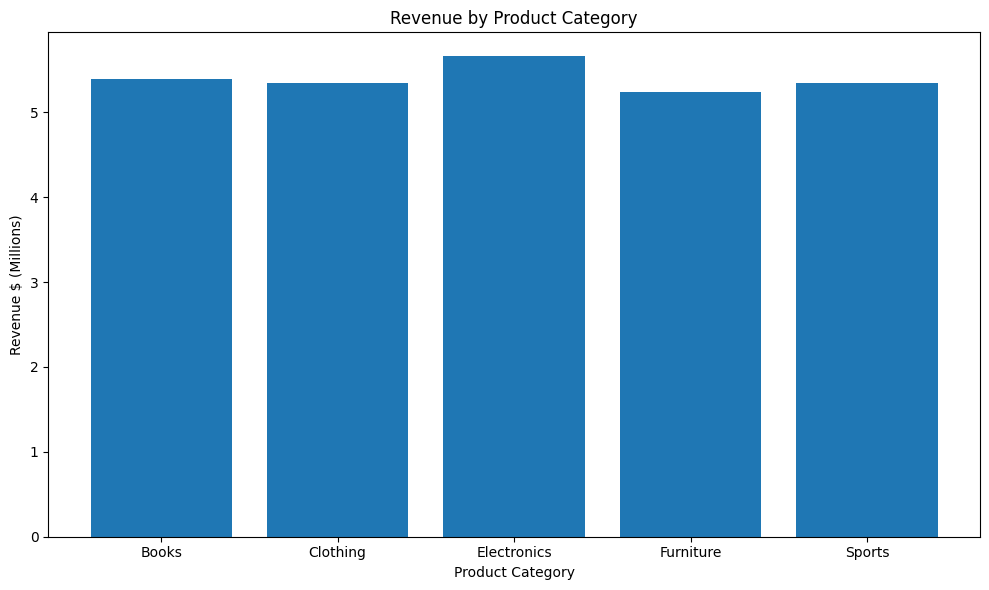

In [100]:
# Create Bar Chart for Revenue by Product Category

plt.figure(figsize=(10,6))

plt.bar(
    product_summary_v2["product_category"],
    product_summary_v2["revenue_millions"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue $ (Millions)")

plt.tight_layout()
plt.show()

---

### Return Rate by Product Category
- Chart Type: Bar Chart
- Purpose: Identify categories with elevated return rates.

In [101]:
# Re-use the below table - updated original table to sort by return product category
product_summary_v2

,product_category,order_count,revenue,avg_order_value,return_rate,revenue_millions
0,Books,1999,5394026.35,2727.01,11.955978,5.394026
1,Clothing,1989,5349226.55,2725.03,12.217195,5.349227
2,Electronics,2020,5658086.01,2827.63,10.742574,5.658086
3,Furniture,1978,5235459.31,2667.07,10.970677,5.235459
4,Sports,2004,5348757.99,2693.23,11.227545,5.348758


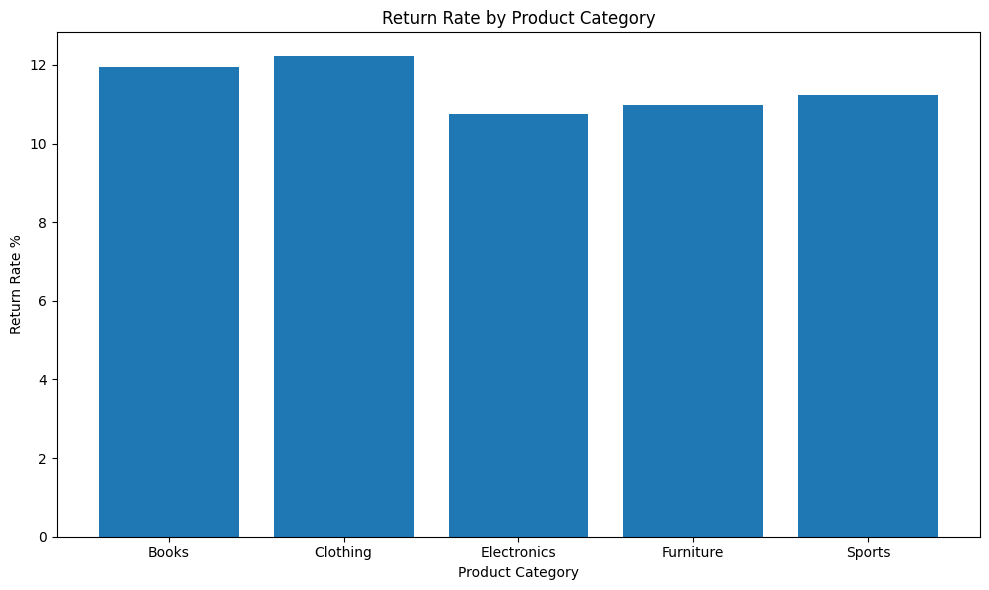

In [102]:
# Create vertical bar chart
plt.figure(figsize=(10,6))

plt.bar(
    product_summary_v2["product_category"],
    product_summary_v2["return_rate"]
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate %")

plt.tight_layout()
plt.show()

---

### Revenue by State (Top 10)
- Chart Type: Horizontal Bar Chart
- Purpose: Highlight the states generating the most revenue.

In [103]:
# Create new table to use

top_10_revenue_by_state = (analysis_df.groupby("state")["revenue_per_order"]
                                .sum()
                                .reset_index()
                                .rename(columns={"revenue_per_order": "Revenue by State"})
                                .sort_values(by="Revenue by State", ascending=False))

top_10_revenue_by_state["Revenue by State $ (Millions)"] = top_10_revenue_by_state["Revenue by State"] / 1_000_000

top_10_revenue_by_state

,state,Revenue by State,Revenue by State $ (Millions)
2,CO,3.507872e+06,3.507872
1,CA,3.376726e+06,3.376726
3,FL,3.353902e+06,3.353902
0,AZ,3.327535e+06,3.327535
5,NY,3.245572e+06,3.245572
7,TX,3.240614e+06,3.240614
8,WA,3.218540e+06,3.218540
6,OR,3.109583e+06,3.109583
4,Missing State Code,6.052125e+05,0.605213


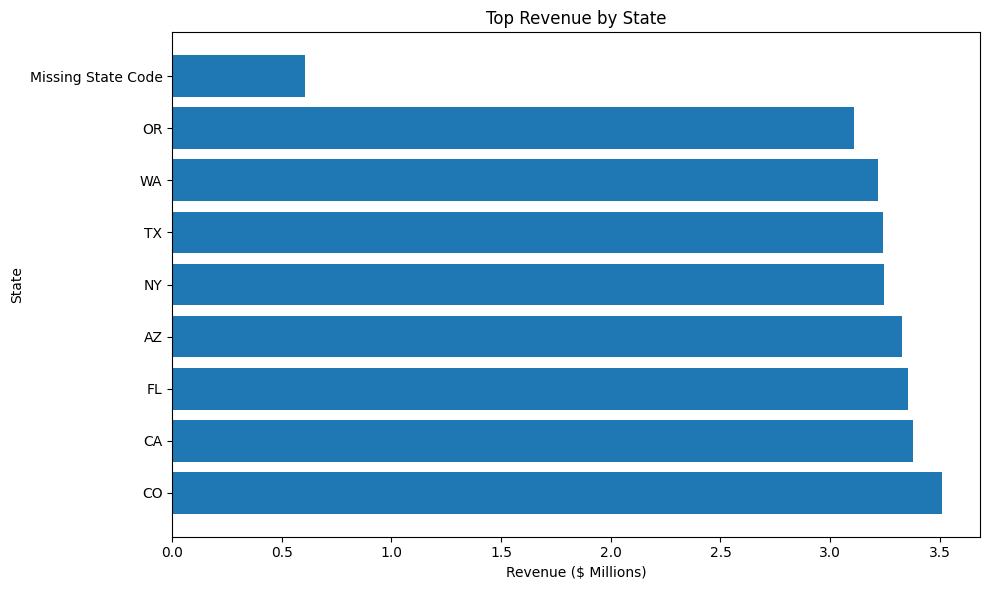

In [104]:
# Create horizontal bar chart

plt.figure(figsize=(10,6))

plt.barh(
    top_10_revenue_by_state["state"],
    top_10_revenue_by_state["Revenue by State $ (Millions)"]
)

plt.title("Top Revenue by State")
plt.xlabel("Revenue ($ Millions)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

---

#### Orders by Month

- Chart Type: Line Chart
- Purpose: Identify seasonality and ordering trends throughout the year.

In [105]:
# Create a better visual month_year column
analysis_df["order_month_year"] = analysis_df["order_date"].dt.strftime("%m-%Y")

In [106]:
order_by_month = (analysis_df.groupby("order_month_year")["order_id"]
                .count()
                .reset_index()
                .rename(columns={"order_id": "order_count"}))
order_by_month

,order_month_year,order_count
0,01-2025,896
1,02-2025,769
2,03-2025,820
3,04-2025,812
4,05-2025,895
5,06-2025,779
6,07-2025,858
7,08-2025,876
8,09-2025,836
9,10-2025,815


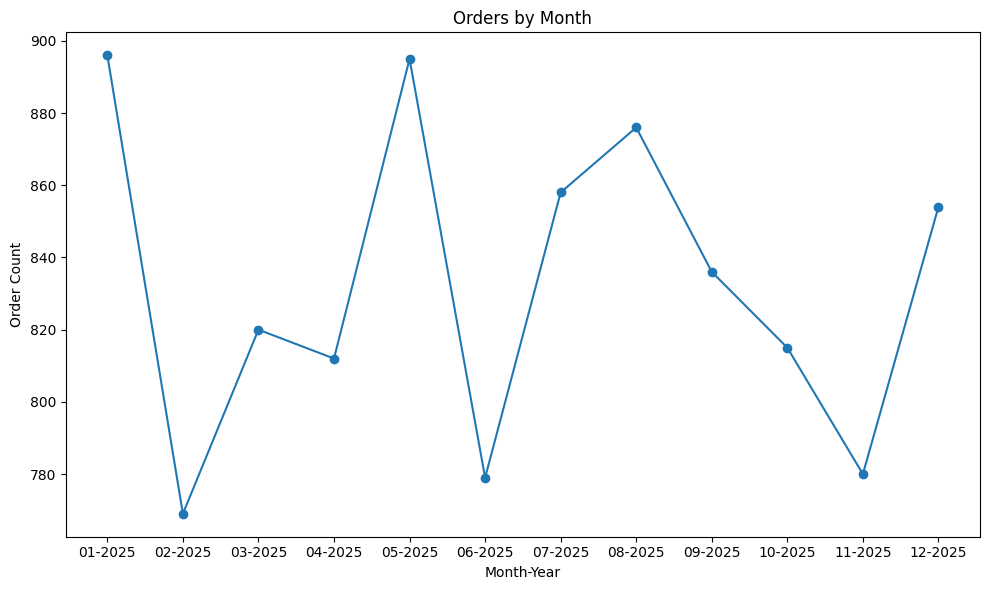

In [107]:
# Create line graph 

plt.figure(figsize=(10,6))

plt.plot(
    order_by_month["order_month_year"], 
    order_by_month["order_count"], 
    marker="o"
)

plt.title("Orders by Month")
plt.xlabel("Month-Year")
plt.ylabel("Order Count")

plt.tight_layout()
plt.show()

---

### Distribution of Order Values

- Chart Type: Histogram
- Purpose: Understand the distribution of order values and visualize the impact of outliers.

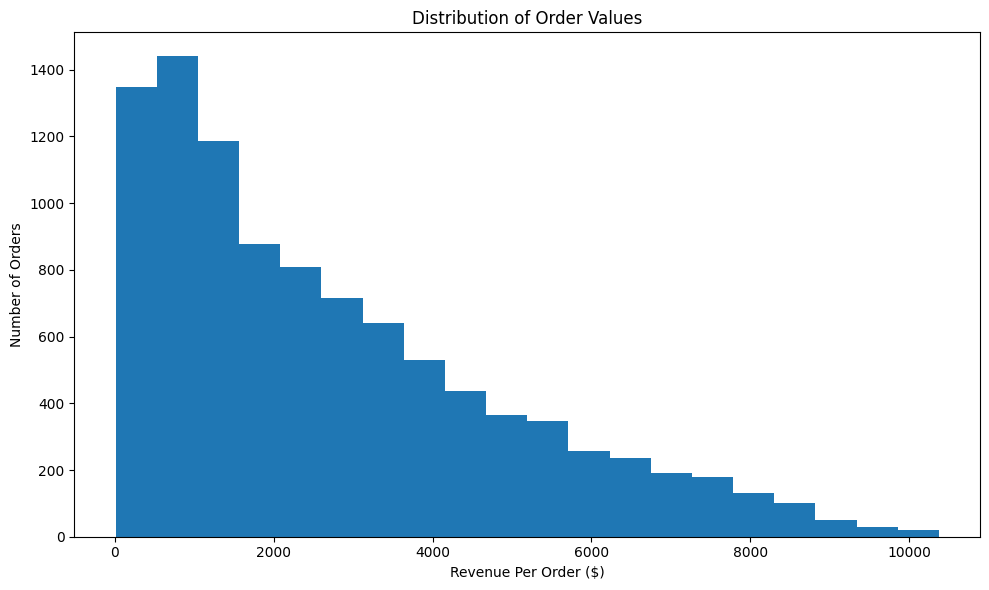

In [108]:
# Create histogram out of order values 
plt.figure(figsize=(10, 6))

plt.hist(
    analysis_df["revenue_per_order"],
    bins=20
)

plt.title("Distribution of Order Values")
plt.xlabel("Revenue Per Order ($)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [109]:
analysis_df["revenue_per_order"].describe()

count     9891.000000
mean      2728.294026
std       2223.099242
min          9.880000
25%        934.589000
50%       2137.400000
75%       4012.778500
max      10374.490000
Name: revenue_per_order, dtype: float64

## Stage 9: Findings

- No specific findings to share. This stage was purely focused on creating visuals. 

---

## Stage 10: Executive Summary

### **Business Performance**

- A total of **9,990 orders** were analyzed after data cleaning and preparation.
- Total revenue generated (excluding extreme outlier orders) was **$26.99M**.

### **Revenue Performance**

- **Colorado** generated the highest revenue at **$3.51M**.
- **Electronics** generated the highest product category revenue at **$5.66M**.

### **Operational Insights**

- **Clothing** exhibited the highest return rate at **12.2%**.
- The average shipping time across all orders was **5.03 days**.

### **Data Quality Summary**

- Removed **50 duplicate records** during the data cleaning process.
- Addressed and investigated missing values prior to analysis.
- Identified **10 extreme outlier orders** that materially impacted business performance metrics.

### **Recommendations**

- Investigate the drivers of elevated return rates within the Clothing category.
- Exclude extreme outlier orders from routine business performance reporting to prevent metric distortion.
- Continue monitoring revenue performance by state and product category to identify growth opportunities.
- Review operational processes that may contribute to product returns and customer friction.

### **Conclusion**

The analysis identified strong revenue performance in both Colorado and the Electronics category while highlighting operational challenges related to product returns. Data quality issues were successfully addressed prior to analysis, resulting in a reliable dataset for business reporting and decision-making. The findings provide a foundation for future revenue optimization and operational improvement initiatives.